##### 常數

In [53]:
NAME = "pose1-1"

VIDEO = f"../../../../resources/video/20240702/2/{NAME}.mp4"  # 影片路徑
MODEL = "./models/BlazePose/pose_landmarker_full.task"  # 模型路徑

OUT_PATH = f"./output_video/{NAME}.mp4"  # 影片輸出路徑

#### 套件

In [54]:
from pathlib import Path
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import cv2

from mediapipe.tasks.python.core.base_options import BaseOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import (
    VisionTaskRunningMode,
)
from mediapipe.tasks.python.vision.pose_landmarker import (
    PoseLandmarker,
    PoseLandmarkerOptions,
)

In [55]:
from mpl_toolkits.mplot3d.axes3d import Axes, Axes3D
from mediapipe.tasks.python.vision.pose_landmarker import PoseLandmarkerResult

In [56]:
from src.mediapipe_lib.base import (
    PoseResult,
    ResultAnalyzer,
    LhcPoseListAnalyzer,
)
from src.draw_template import (
    draw_debug_in_img,
    draw_kpt_position_in_img,
    get_bones_plot_axes,
)
from src.utils.plot_painter import (
    set_data_range,
    set_plot_labels,
    plot_to_opencv_img,
    draw_bool_list_line_chart,
    draw_pose_result_line_chart,
)
from src.server_api import get_video_json_result

#### 忽略警告

In [57]:
import warnings

warnings.filterwarnings("ignore")

#### 函式

##### 設定圖表座標資訊

In [58]:
def set_axes_info(is_3d: bool, ax: Axes | Axes3D) -> Axes | Axes3D:
    """設定圖表座標資訊

    Args:
        is_3d (bool): 是否為 3D 姿勢
        ax (Axes | Axes3D): 圖表座標

    Returns:
        Axes | Axes3D: 圖表座標
    """

    # 設定圖表座標資訊
    if not is_3d:
        set_plot_labels("x", "y", ax=ax)  # 設定標籤
        set_data_range([0, 1], [1, 0], ax=ax)  # 設定資料範圍
    else:
        set_plot_labels("x", "z", "y", ax)  # 設定標籤
        set_data_range([-1, 1], [-1, 1], [0, 2], ax)  # 設定資料範圍

    return ax

##### 繪製分析結果圖表

In [59]:
def draw_result_plot(
    result: PoseLandmarkerResult,
    figsize: tuple[float, float] = (6.4, 4.8),
    is_3d: bool = False,
) -> cv2.typing.MatLike:
    """繪製分析結果圖表

    Args:
        result (PoseLandmarkerResult): 姿勢結果
        figsize (tuple[float, float], optional): 圖表大小. Defaults to (6.4, 4.8).
        is_3d (bool, optional): 是否為 3D 姿勢. Defaults to False.

    Returns:
        cv2.typing.MatLike: 分析結果圖片
    """
    # 建立分析器
    analyzer = ResultAnalyzer(PoseResult(result))

    # 建立圖表q
    fig = plt.figure(figsize=figsize)
    ax: Axes3D = fig.add_subplot(projection="3d")
    ax.view_init(0, 0, 0)

    # 設定圖表座標資訊
    set_axes_info(is_3d, ax)

    # 繪製表格
    if len(result.pose_world_landmarks) > 0:
        ax.set_title(analyzer.get_lhc_label(is_3d), fontsize=40)
        get_bones_plot_axes(result, is_3d=is_3d, ax=ax)
        ax.legend()
    else:
        ax.set_title("NO DATA")

    # 將圖表轉換成圖片格式
    rgb = cv2.cvtColor(plot_to_opencv_img(fig), cv2.COLOR_RGBA2RGB)

    plt.close(fig)  # 關閉圖表

    return rgb

#### 開始測試

In [60]:
# 模型設定
options = PoseLandmarkerOptions(
    base_options=BaseOptions(MODEL), running_mode=VisionTaskRunningMode.VIDEO
)

# 輸出路徑
out_path = Path(OUT_PATH)
# 建立放置輸出檔案的資料夾
if not out_path.parent.exists():
    out_path.parent.mkdir(parents=True)  

is_3d = True  # 使用 3D 模型

# 影片輸出
zoom_ratio = 0.5  # 影片縮放倍率
fourcc = cv2.VideoWriter.fourcc(*"mp4v")  # fourcc 碼
fps = 30  # 幀率

In [61]:
cap = cv2.VideoCapture(VIDEO)  # 取得串流資訊
lhc_analyzer = LhcPoseListAnalyzer()  # LHC 姿勢分析物件

# 影片大小
cap_size = np.array(
    [
        int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    ]
)
### 縮放原始影片大小
cap_size = (cap_size * zoom_ratio).astype(np.uint)
# 表格大小
plot_size = np.array([cap_size[0] * 2, cap_size[1]])
# 影片輸出寬高
out_width = cap_size[0] + plot_size[0]
out_height = cap_size[1]

# 建立模型物件
landmarker = PoseLandmarker.create_from_options(options)

# 影片輸出物件
video_out = cv2.VideoWriter(str(out_path), fourcc, fps, (out_width, out_height))

# 預設輸出影像幀
default_frame = np.zeros((out_height, out_width, 3))

# 進行串流
while cap.isOpened():
    # 抓取影像
    ret, frame = cap.read()
    if not ret:
        cv2.destroyAllWindows()
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # 取得並儲存影像分析結果
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    result = landmarker.detect_for_video(mp_img, int(cap.get(cv2.CAP_PROP_POS_MSEC)))

    # 如果成功在圖片中取得人體姿勢，則加入結果到 lhc_analyzer 中
    if len(result.pose_landmarks) > 0:
        lhc_analyzer += [result]

    ### 縮放原始影片大小
    resized_frame = cv2.resize(frame, cap_size)

    ### 繪製分析結果
    mp_img = draw_kpt_position_in_img(result, resized_frame)  # 2D 關鍵點
    mp_img = draw_debug_in_img(result, mp_img, is_3d)  # 偵錯資訊
    plot_img = draw_result_plot(result, plot_size / 100, is_3d)  # 分析圖表
    # 組合原始圖片和分析圖表
    out_frame = np.concatenate((plot_img, mp_img), axis=1)

    # 儲存影片幀
    video_out.write(out_frame)

    # 顯示 OpenCV 視窗畫面
    cv2.imshow("debug", out_frame)
    if cv2.waitKey(1) == ord("q"):
        cv2.destroyAllWindows()
        break


cap.release()
video_out.release()
landmarker.close()
print("finish")

Can't receive frame (stream end?). Exiting ...
finish


In [62]:
if True:
    results = get_video_json_result(VIDEO)
    for key, val in results.items():
        print(key, val, sep='  \t')

Can't receive frame (stream end?). Exiting ...
extra scores: [3. 3. 0. 0.]
sum of extra scores: 6.0
extra scores: [3. 3. 0. 0.]
sum of extra scores: 6.0
start  	A4
end  	A4
extra 1  	FREQUENTLY_OR_CONSTANTLY
extra 2  	FREQUENTLY_OR_CONSTANTLY
extra 3  	RARELY
extra 4  	RARELY
pose score  	15
extra score  	6.0
total score  	21.0


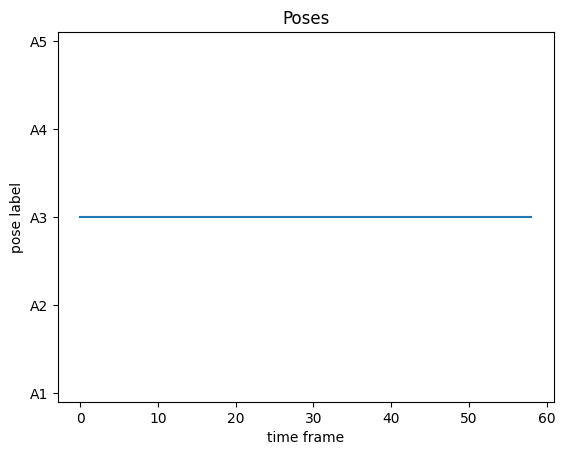

In [63]:
if True:
    plt.title("Poses")
    plt.show(draw_pose_result_line_chart(lhc_analyzer.get_lhc_label_list(is_3d)))

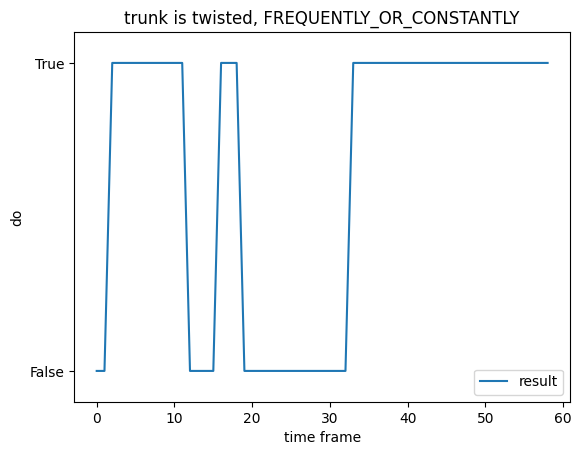

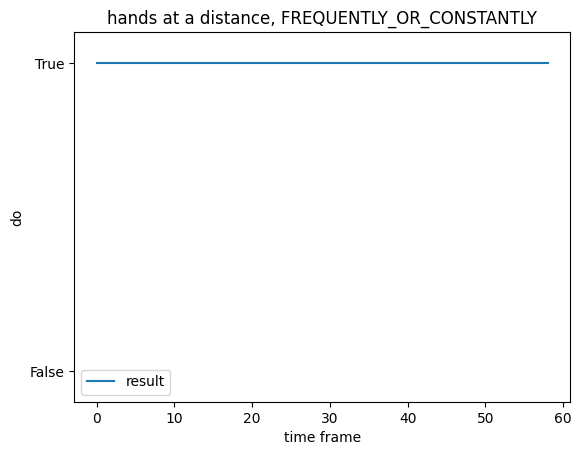

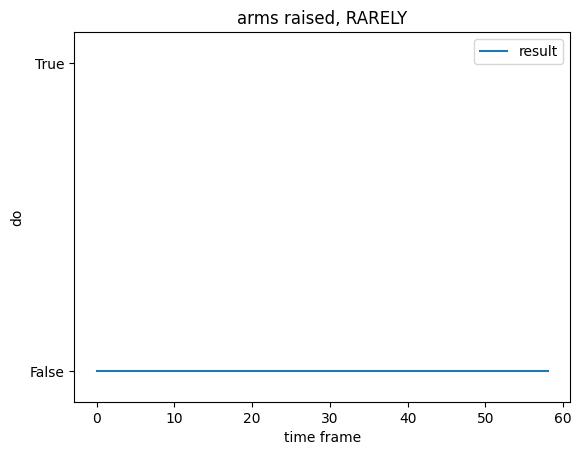

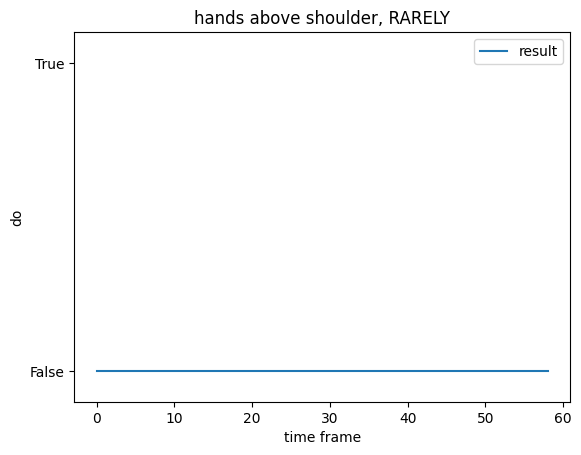

In [64]:
if True:
    # 軀幹扭轉/側傾
    plt.title(
        f"trunk is twisted, {lhc_analyzer.get_frequency_of_trunk_is_twisted(is_3d).name}"
    )
    draw_bool_list_line_chart(lhc_analyzer.get_trunk_is_twisted_list(is_3d), "result")
    plt.legend()
    plt.show()


if True:
    # 手或重心遠離身體
    plt.title(
        f"hands at a distance, {lhc_analyzer.get_frequency_of_hands_at_a_distance(is_3d).name}"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_at_a_distance_list(is_3d), "result"
    )
    plt.legend()
    plt.show()

if True:
    # 手臂抬舉，手的水平位於手肘與肩膀之間
    plt.title(f"arms raised, {lhc_analyzer.get_frequency_of_arms_raised(is_3d).name}")
    draw_bool_list_line_chart(lhc_analyzer.get_arms_raised_list(is_3d), "result")
    plt.legend()
    plt.show()

if True:
    # 手高過肩膀
    plt.title(
        f"hands above shoulder, {lhc_analyzer.get_frequency_of_hands_above_shoulder(is_3d).name}"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_above_shoulder_list(is_3d), "result"
    )
    plt.legend()
    plt.show()

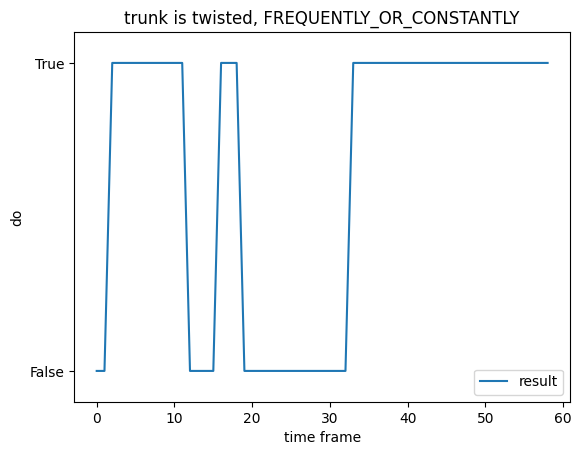

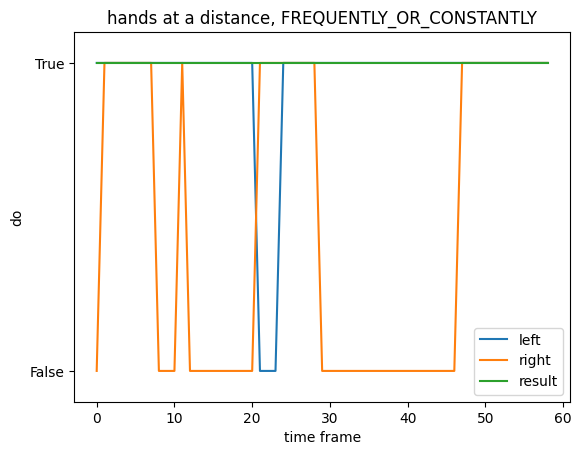

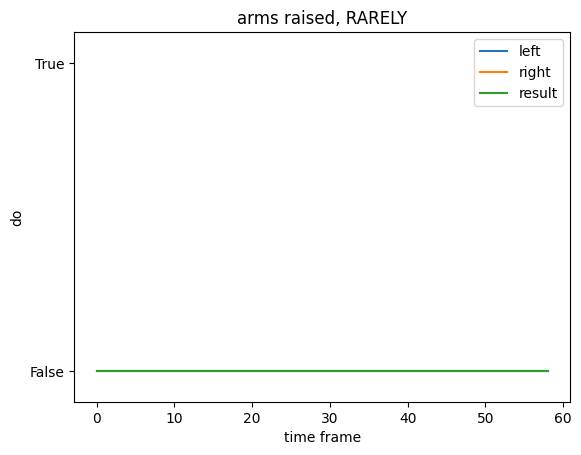

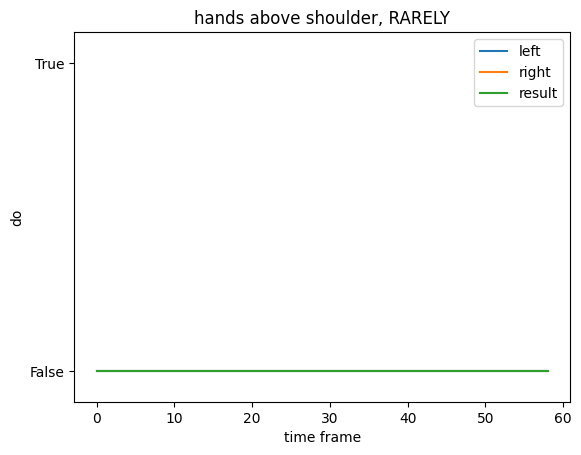

In [65]:
if True:
    # 軀幹扭轉/側傾
    plt.title(
        f"trunk is twisted, {lhc_analyzer.get_frequency_of_trunk_is_twisted(is_3d).name}"
    )
    draw_bool_list_line_chart(lhc_analyzer.get_trunk_is_twisted_list(is_3d), "result")
    plt.legend()
    plt.show()


if True:
    # 手或重心遠離身體
    plt.title(
        f"hands at a distance, {lhc_analyzer.get_frequency_of_hands_at_a_distance(is_3d).name}"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_at_a_distance_list_by_one_side(True, is_3d), "left"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_at_a_distance_list_by_one_side(False, is_3d), "right"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_at_a_distance_list(is_3d), "result"
    )
    plt.legend()
    plt.show()

if True:
    # 手臂抬舉，手的水平位於手肘與肩膀之間
    plt.title(f"arms raised, {lhc_analyzer.get_frequency_of_arms_raised(is_3d).name}")
    draw_bool_list_line_chart(
        lhc_analyzer.get_arms_raised_list_by_one_side(True, is_3d), "left"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_arms_raised_list_by_one_side(False, is_3d), "right"
    )
    draw_bool_list_line_chart(lhc_analyzer.get_arms_raised_list(is_3d), "result")
    plt.legend()
    plt.show()

if True:
    # 手高過肩膀
    plt.title(
        f"hands above shoulder, {lhc_analyzer.get_frequency_of_hands_above_shoulder(is_3d).name}"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_above_shoulder_list_by_one_side(True, is_3d), "left"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_above_shoulder_list_by_one_side(False, is_3d), "right"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_above_shoulder_list(is_3d), "result"
    )
    plt.legend()
    plt.show()